# __Demo 3 - Land Surface Temperature raster analysis__
### Basic usage example of processing and representing __Land Surface Temperature__ analysis data.

#### __What is Land Surface Temperature (LST)?__
Land Surface Temperature (LST) represents the thermal emission from the Earth's surface as detected by satellite sensors. It indicates how hot the surface of the land would feel to the touch, and is derived from the thermal infrared (TIR) band of satellites such as Landsat 8 and Landsat 9.

In this analysis, LST is calculated from the LWIR11 band using the following equation:

$$
LST=((lwir11×0.00341802)+149.0)−273.15
$$

This converts the digital values from the satellite’s thermal band into surface temperature in degrees Celsius (°C).

#### __How can LST be used?__
Surface temperature is a key environmental variable that helps understand energy exchange between the land and atmosphere. It is widely used in:

* Urban heat island analysis – identifying and monitoring hotspots in cities.
* Climate and environmental monitoring – assessing temperature trends and heat stress on ecosystems.
* Agricultural management – detecting crop water stress and evapotranspiration rates.
* Hydrology and drought studies – estimating soil moisture and surface energy balance.
* Public health and urban design – supporting heat mitigation strategies through green infrastructure and surface material assessment.

#### __About this notebook__
This notebook displays a __demo process to be used be used to calculate LST (refered in notebook as just 'Temperature')__ within a given area of interest, __and then represent the data__ using a hexgrid and the Observatory's design style.

The notebook consists of the following steps:
* __Import libraries__
* __Analysis configuration__
* __Prepare the area of interest by using the hex with larger size__
* __Initialize PCRasterData Class__
* __Execute main process__
* __Load the requested hexgrid resolutions for the output__
* __Transfer raster data to polygons (hexagonal grid)__
* __Land Surface Temperature visualization__

## __Import libraries__

In order to use the functions required to process and represent data, we've developed a code library called `odc`, which stores functions that use other python libraries for the analysis and representation of data.

In [1]:
from pathlib import Path
current_path = Path().resolve()
for parent in current_path.parents:
    if parent.name == "odc":
        project_root = parent
        break
print(project_root)

import os
import sys

module_path = os.path.abspath(os.path.join(project_root))
if module_path not in sys.path:
    sys.path.append(module_path)
    print("Path found")
    import odc

/home/jovyan/odc
Path found


In [2]:
import pandas as pd
import geopandas as gpd
#import odc
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

## __Analysis configuration__

This cell specifies the location of input data and other parameters used within the Temperature analysis.

In [3]:
# --------------- Location of input data
# Area of interest - Directory with location of input layer containing a polygon geometry that defines the area of interest were the analysis is to be performed.
aoi_dir = "../data/demo_files/aoibuffer_saltillo_32614.gpkg"

# --------------- Analysis parameters
# index_analysis (str) - Index to be analysed
index_analysis = "temperature"
# aoi_name (str) - Name of area of interest
aoi_name = 'Saltillo'
# start_date (str) - Stard date for the analysis in format "YYYY-MM-DD"
start_date = "2025/01/01"
# end_date (str) - End date for the analysis in format "YYYY-MM-DD"
end_date = "2025/10/31"
# tmp_dir (str) Temporary directory where raster data will be saved
tmp_dir = "../data/demo_files/temperature_process"
# projection_crs (str) - CRS used when projecting features to perform geoprocessing (e.g. "6372" could be used anywere in Mexico)
# [Optional, function defaults to "EPSG:6372"]
projection_crs = "EPSG:32614"
# satellite (str) - Name of satellite where rasters are downloaded from.
# For temperature analysis, you cannot use "sentinel-2-l2a" (the default value in PCRasterData()), since Sentinel-2 rasters do not contain thermal bands.
# Use "landsat-c2-l2" with platforms 8 or 9 (defined in sat_query) instead.
satellite = "landsat-c2-l2"
# sat_query (dict) - Platforms and Maximum cloud coverage for downloading rasters.
sat_query = {"eo:cloud_cover": {"lt": 10},
             "platform": {"in": ["landsat-8", "landsat-9"]}
            }
# band_name_dict (dict) - Dictionary with spectral band names (example for landsat-c2-l2 8/9 Temperature). If bands are provided by satellite in different resolutions, must set dict values to [True] instead of [False]
band_name_dict = {'lwir11':[False]}
# index_equation (lst) - List with equation for index calculation using common band names (example for landsat-c2-l2 8/9 Temperature)
index_equation = ["((lwir11*0.00341802) + 149.0)-273.15"]
# Output hexgrid resolution (list with 2 values between 8 and 11) - Specifies resolution of H3 hexagonal cells. For more information consult resolutions in https://h3geo.org/
output_resolutions = [8,9]

# --------------- Output saving
# Output directory for hexagons (str) - Directory with the location where the output hexs with raster analysis will be saved
output_dir = "../data/demo_files/outputs_temperature/"

## __Prepare the area of interest by using the hex with larger size__

The area of interest must be converted into hexs __in order to consider the territory covered by the largest hexagonal grid__ in the raster download and processing.

<Axes: >

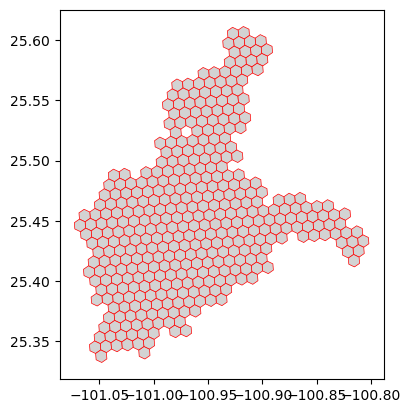

In [4]:
# --------------- Prepare the area of interest CRS
aoi_gdf = gpd.read_file(aoi_dir)
if aoi_gdf.crs is None:
    aoi_gdf = aoi_gdf.set_crs('EPSG:4326')
elif aoi_gdf.crs != 'EPSG:4326':
    aoi_gdf = aoi_gdf.to_crs('EPSG:4326')

# Create area of interest with biggest hexs
big_res = min(output_resolutions)
poly = aoi_gdf.to_crs(projection_crs).buffer(500).reset_index()
poly = poly.rename(columns={0:'geometry'})
poly = gpd.GeoDataFrame(poly, geometry='geometry')
poly = poly.to_crs("EPSG:4326")
hex_aoi = odc.create_hexagonal_grid(aoi_gdf, big_res)

# Show input data (This part creates the following map for visualization purposes)
fig,ax = plt.subplots()
hex_aoi.plot(ax=ax,zorder=1, facecolor='lightgray',edgecolor='red',lw=.5)

## __Initialize PCRasterData Class__

The function __PDRasterData__ class was developed to simplify the process of adding up all variables and processes regarding the analysis of raster data.

In [5]:
kwargs = {"projection_crs":projection_crs,
          "satellite":satellite,
          "sat_query":sat_query,
         }
raster_process = odc.PCRasterData(gdf=hex_aoi,
                                  index_analysis=index_analysis,
                                  area_of_analysis_name=aoi_name,
                                  start_date=start_date,
                                  end_date=end_date,
                                  tmp_dir=tmp_dir,
                                  band_name_dict=band_name_dict,
                                  index_equation=index_equation,
                                  **kwargs
                                 )

## __Execute main process__

The method __odc.download_raster_from_pc(self)__ contains the main workflow to download and process satellite raster data.

This method orchestrates the complete raster processing pipeline:
1. Creates spatial and temporal areas of interest
2. Queries Planetary Computer for available satellite imagery
3. Downloads and mosaics raster data by month
4. Calculates indices and performs quality control
5. Interpolates missing data if requested

In [6]:
df_raster_inventory = raster_process.download_raster_from_pc()

# Show
print(df_raster_inventory.shape)
df_raster_inventory.head(2)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [05:15<00:00, 31.55s/it]


(10, 6)


,year,month,data_id,able_to_download,download_method,interpolate
0,2025,1,1,0.0,could_not_process,1
1,2025,2,1,0.0,could_not_process,1


## __Load the requested hexgrid resolutions for the output__

The raster analysis will be converted to hexagonal data with requested resolutions. __This step loads all necessary hexagons.__

In [7]:
# The first resolution is already loaded and functions as a base polygon from which the rest are created
hex_gdf = hex_aoi.copy()
hex_gdf.rename(columns={f'hex_id_{big_res}':'hex_id'}, inplace=True)
hex_gdf['res'] = big_res
print(f'Prepared hexgrid res {big_res}')

# Create a list with resolutions ordered sequentially
res_list=[]
for r in range(output_resolutions[0],output_resolutions[-1]+1):
    if r not in res_list:
        res_list.append(r)

# If user inputed just one resolution (e.g. output_resolutions = [8:8]), cannot append more resolutions.
if len(res_list) <= 1:
    print(f"Loaded hexgrids with the following resolutions: {list(hex_gdf.res.unique())}.")
# If there are more resolutions, load one by one and append them to hex_gdf
else:
    hex_diss = hex_gdf.dissolve()
    for r in res_list:
        # Skip first resolution, it is already loaded
        if r == big_res:
            continue
        # Load hexgrid of 'r' resolution
        hex_tmp = odc.create_hexagonal_grid(hex_diss, r)
        # Format hexgrid of 'r' resolution
        hex_tmp.rename(columns={f'hex_id_{r}':'hex_id'}, inplace=True)
        hex_tmp['res'] = r
        # Concatenate to hex_gdf (which contains all resolutions)
        hex_gdf = pd.concat([hex_gdf, hex_tmp])
        print(f'Loaded hexgrid res {r}')
        del hex_tmp
    del hex_diss

# Show
print(f"Loaded hexgrids with the following resolutions: {list(hex_gdf.res.unique())}.")
print(hex_gdf.crs)
print(hex_gdf.shape)
hex_gdf.head(2)

Prepared hexgrid res 8
Loaded hexgrid res 9
Loaded hexgrids with the following resolutions: [8, 9].
EPSG:4326
(3080, 3)


,hex_id,geometry,res
0,8848a2b6ddfffff,"POLYGON ((-100.96232 25.4956, -100.95758 25.49...",8
1,8848a04cb1fffff,"POLYGON ((-100.93134 25.42701, -100.92661 25.4...",8


## __Transfer raster data to polygons (hexagonal grid)__

The __odc.RasterToPolygon__ class was developed to simplify the process of transfering the data from raster to polygons (in this case, to a hexagonal grid). Since it recieves a gdf containing the input GeoDataFrame with polygon geometries, and different resolutions overlap, __it is initialized and used for each resolution.__

In [8]:
hex_analysis_gdf = gpd.GeoDataFrame()
hex_analysis_df = pd.DataFrame()

# Raster to hex function for each resolution (saves output)
for r in list(hex_gdf.res.unique()):

    print(f'---------------------------------------')
    print(f'STARTING processing for resolution {r}.')

    ##### Filter hexagons of specified resolution #####
    hex_gdf_res = hex_gdf.loc[hex_gdf.res==r].copy()
    hex_gdf_res = hex_gdf_res.reset_index(drop=True)

    ##### Initialize RasterToPolygon Class #####
    print(f'Defined odc.RasterToPolygon class for resolution {r}.')
    polygon_process = odc.RasterToPolygon(gdf=hex_gdf_res,
                                          feature_unique_id='hex_id',
                                          df_raster_inventory=df_raster_inventory,
                                          index_analysis=index_analysis,
                                          area_of_analysis_name=aoi_name,
                                          tmp_dir=tmp_dir
                                         )
    
    ##### Execute main process #####
    print(f'Executing raster_sumary() function for resolution {r}.')
    gdf_raster_analysis, gdf_raster_df = polygon_process.raster_summary()

    ##### Append processed resolution to overall result #####
    print(f'Finished processing resolution {r}.')
    gdf_raster_analysis['res'] = r
    hex_analysis_gdf = pd.concat([hex_analysis_gdf,gdf_raster_analysis])
    hex_analysis_df = pd.concat([gdf_raster_df,gdf_raster_df])

# Show
print(f"Processed raster data to hexgrids with the following resolutions: {list(hex_analysis_gdf.res.unique())}.")

---------------------------------------
STARTING processing for resolution 8.
Defined odc.RasterToPolygon class for resolution 8.
Executing raster_sumary() function for resolution 8.


Processing years: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.54it/s]


Finished processing resolution 8.
---------------------------------------
STARTING processing for resolution 9.
Defined odc.RasterToPolygon class for resolution 9.
Executing raster_sumary() function for resolution 9.


Processing years: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.86s/it]


Finished processing resolution 9.
Processed raster data to hexgrids with the following resolutions: [8, 9].


The first result of each hexgrid resolution iteration using raster_summary() function is __a GeoDataFrame__ called hex_analysis_gdf (Concatenated in __hex_analysis_gdf__) containing __a statistical summary__ of the raster index analysis __throughout the requested time.__

In [9]:
print(hex_analysis_gdf.crs)
print(hex_analysis_gdf.shape)
hex_analysis_gdf.head(1)

EPSG:4326
(3080, 12)


,hex_id,geometry,temperature_mean,temperature_std,temperature_median,temperature_max,temperature_min,temperature_diff,temperature_tend,temperature_2025,area_of_analysis_name,res
0,8848a2b6ddfffff,"POLYGON ((-100.96232 25.4956, -100.95758 25.49...",38.494091,3.991807,40.040431,44.772727,33.32488,11.447847,0.57864,38.494091,Saltillo,8


The second result is a __DataFrame__ called hex_analysis_df (Concatenated in __hex_analysis_df__) containing the __specific raster index value detected on each specific date__.

In [10]:
# Show
print(hex_analysis_df.shape)
hex_analysis_df.head(1)

(53900, 6)


,hex_id,res,temperature,month,year,area_of_analysis_name
0,8948a0784b7ffff,9,29.973054,1,2025,Saltillo


#### __Save the raster analysis to output directory__

In [11]:
for res in list(hex_analysis_gdf.res.unique()):
    hex_analysis_res = hex_analysis_gdf.loc[hex_analysis_gdf.res==res].copy()
    hex_analysis_res.to_file(output_dir+f'{aoi_name}_{index_analysis}_summary_res{res}', driver="GPKG")

    hex_analysis_res = hex_analysis_df.loc[hex_analysis_df.res==res].copy()
    hex_analysis_res.to_csv(output_dir+f'{aoi_name}_{index_analysis}_breakdown_by_date_res{res}.csv')

    print(f'Finished saving processed index data for resolution {res}.')

Finished saving processed index data for resolution 8.
Finished saving processed index data for resolution 9.


/opt/conda/envs/gds/lib/python3.9/site-packages/pyogrio/raw.py:723: RuntimeWarning: The filename extension should be 'gpkg' instead of '' to conform to the GPKG specification.
  ogr_write(
/opt/conda/envs/gds/lib/python3.9/site-packages/pyogrio/raw.py:723: RuntimeWarning: The filename extension should be 'gpkg' instead of '' to conform to the GPKG specification.
  ogr_write(


## __Land Surface Temperature visualization__

#### __Visualization__ - Showing data on different hexgrid resolutions

For displaying Land Surface Temperature, __two functions were developed:__

Function __odc.plot_temperature_anomaly()__ calls function __odc.plot_temperature()__ with the column set to 'temperature_mean' and calculates the difference from each hexagon to the overall area of interest mean temperature value. Those differences are then categorized in 7 bins from less temperature to more temperature difference.

Function __odc.plot_temperature_tendency()__ calls function __odc.plot_temperature()__ with the column set to 'temperature_tend' and plots the column values by using a Red-yellow-green colorbar. Where red indicates a decrease and green an increase over time.

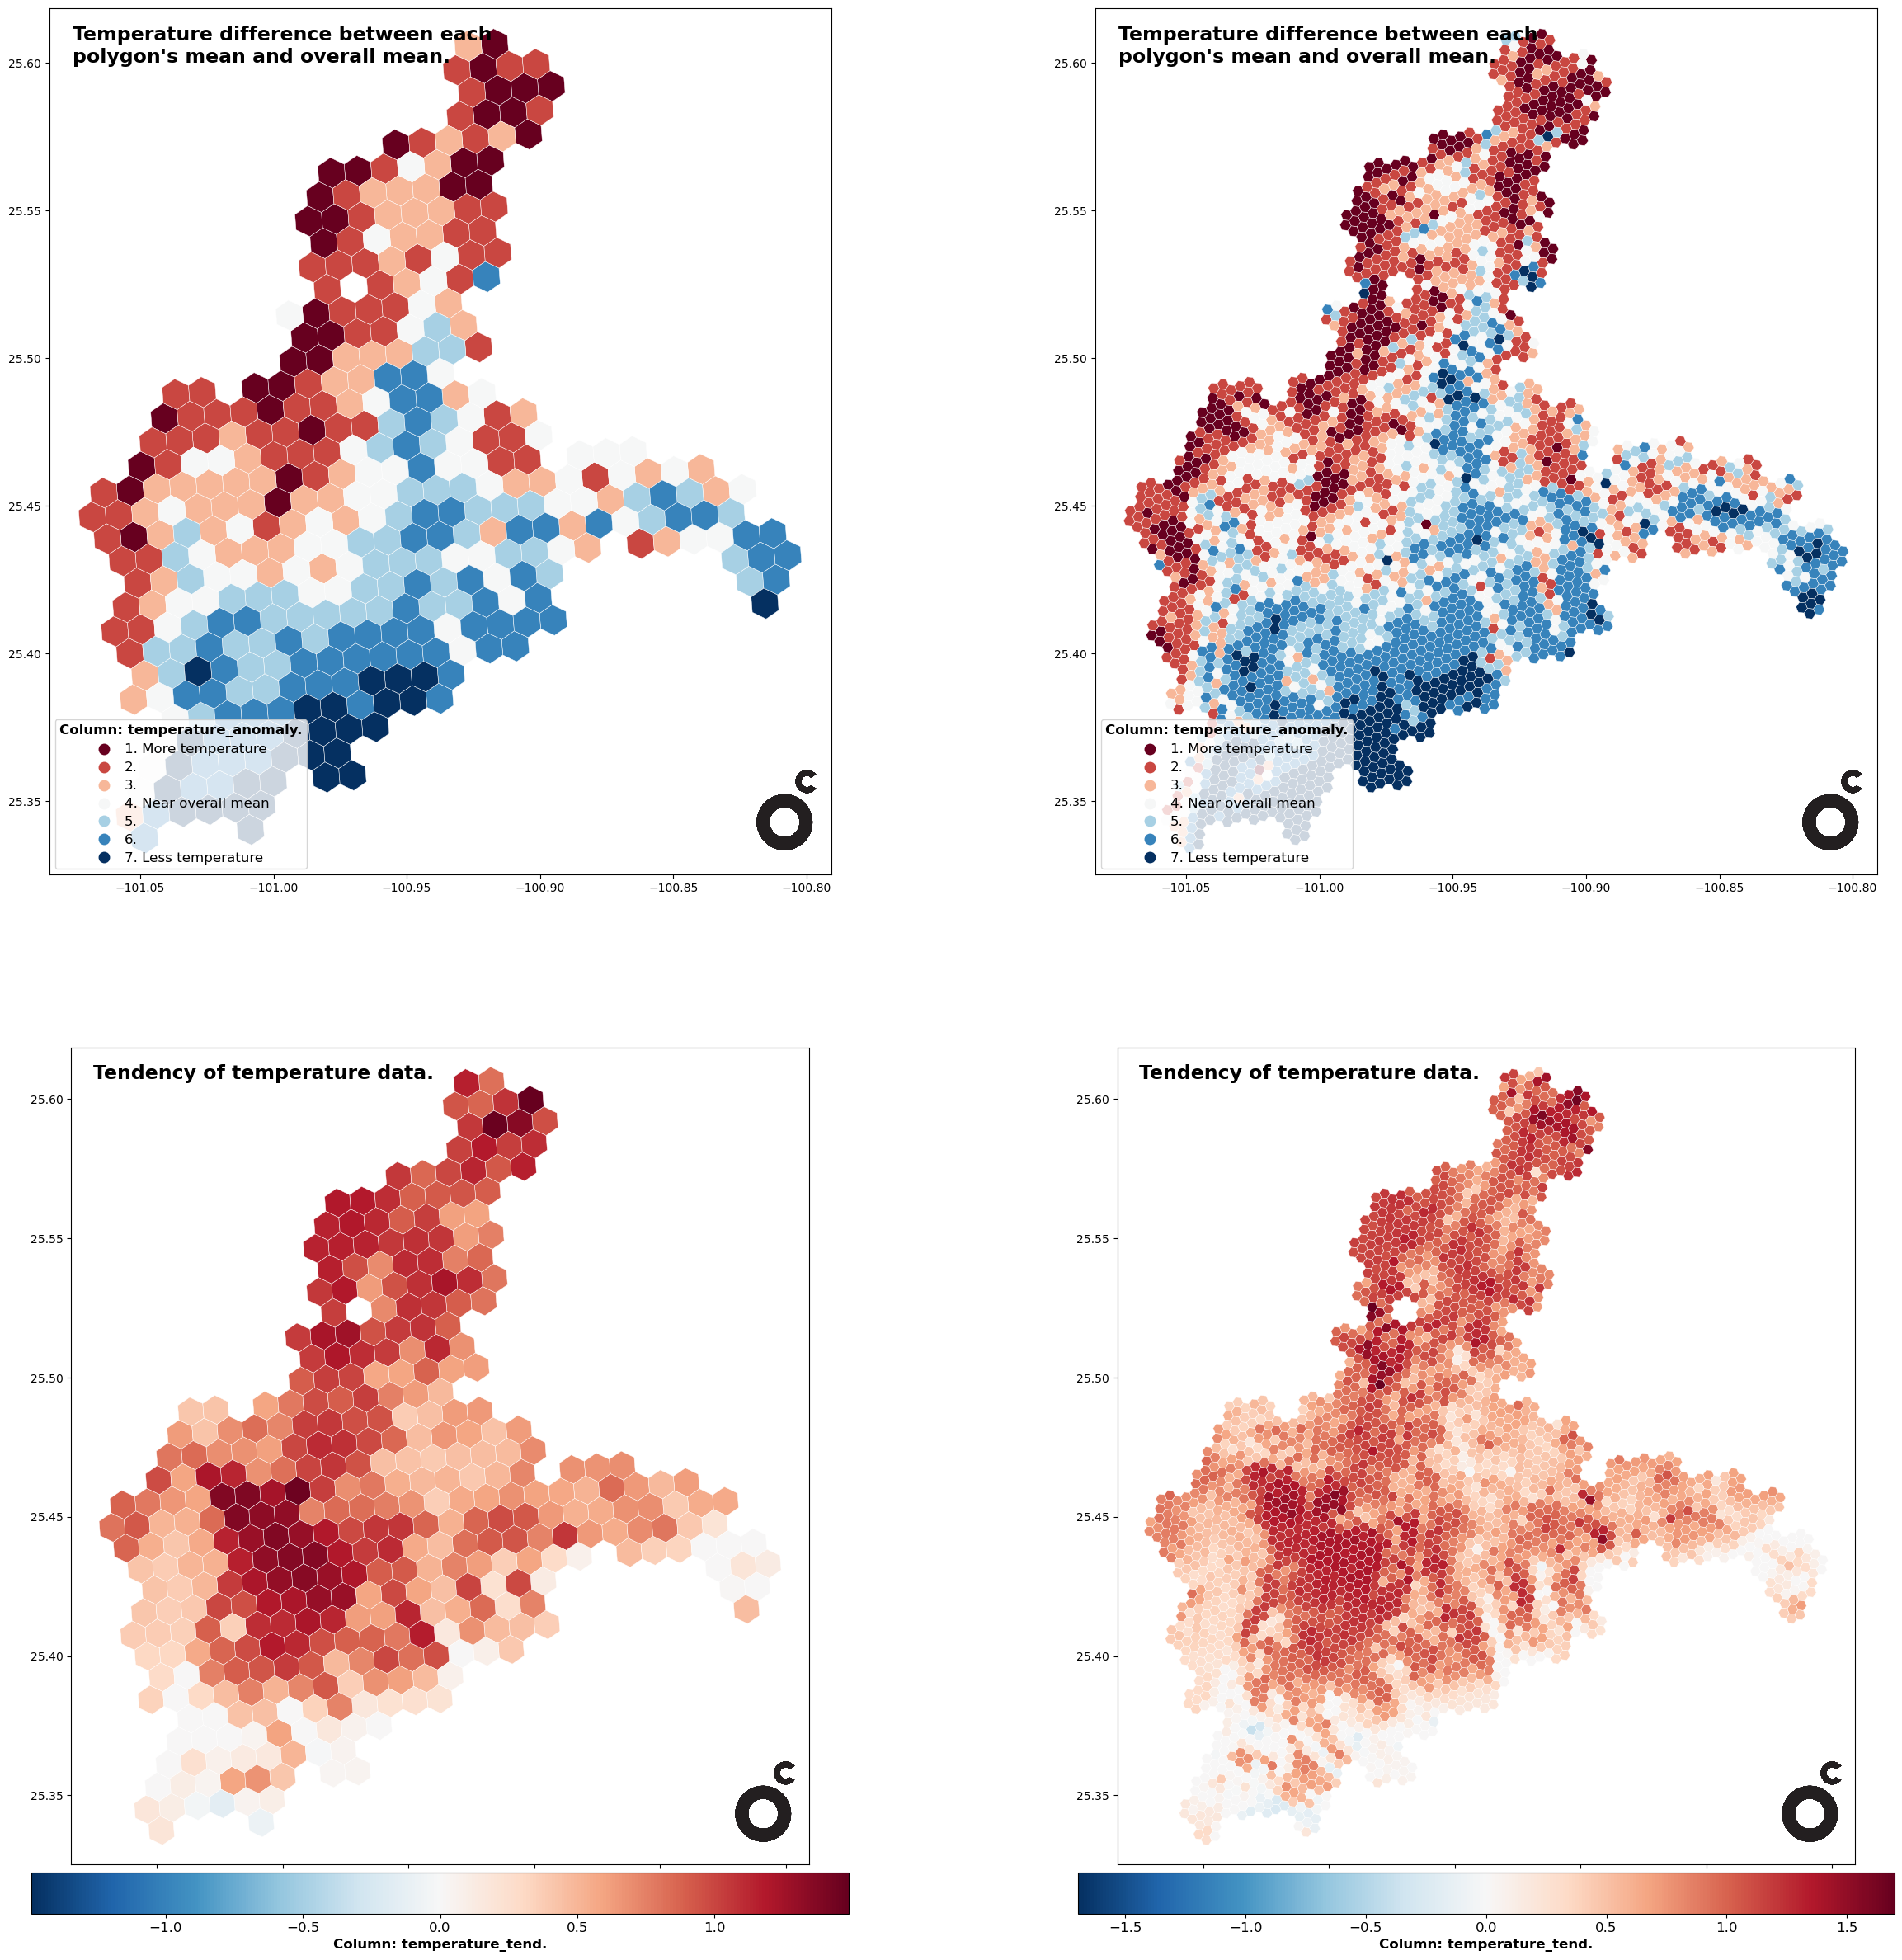

In [13]:
# Extract the hexgrids with the biggest and smallest resolutions
hex_analysis_big_hexs = hex_analysis_gdf.loc[hex_analysis_gdf.res==min(hex_analysis_gdf.res.unique())].copy()
hex_analysis_small_hexs = hex_analysis_gdf.loc[hex_analysis_gdf.res==max(hex_analysis_gdf.res.unique())].copy()

fig,axs = plt.subplots(2,2,figsize=(30,30))

# Plot temperature anomaly data
odc.plot_temperature_anomaly(data_gdf = hex_analysis_big_hexs,
                             ax=axs[0,0]
                            )
odc.plot_temperature_anomaly(data_gdf = hex_analysis_small_hexs,
                             ax=axs[0,1]
                            )

# Plot temperature tendency data
odc.plot_temperature_tendency(data_gdf = hex_analysis_big_hexs,
                              ax=axs[1,0]
                             )
odc.plot_temperature_tendency(data_gdf = hex_analysis_small_hexs,
                              ax=axs[1,1]
                             )

#### __Visualization__ - Adding additional data and saving the result

Keyword arguments can be added to both functions to add additional data to the plot, like the __area of interest's name, and main streets__. Also, the maps __can be saved by to pdf or png__ by using the saving arguments. __The keyword arguments must not be unpacked__ since the argument is passed to function __odc.plot_temperature()__

In [19]:
# Load edges_gdf for showing additional data
edges_gdf = gpd.read_file(f"../data/demo_files/edges_gdf")

# Show
print(edges_gdf.crs)
print(edges_gdf.shape)
edges_gdf.head(1)

/opt/conda/envs/gds/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: File ../data/demo_files/edges_gdf has GPKG application_id, but non conformant file extension
  return ogr_read(


EPSG:4326
(120698, 18)


,u,v,key,osmid,oneway,lanes,name,highway,maxspeed,length,bridge,ref,junction,tunnel,access,width,service,geometry
0,291729314,291730012,0,407465999,True,2,Autopista de Peaje Ojo Caliente-Puerto México,motorway,110,41.403482,None,MEX 57D,None,None,None,None,None,"LINESTRING (-100.80648 25.43824, -100.80647 25..."


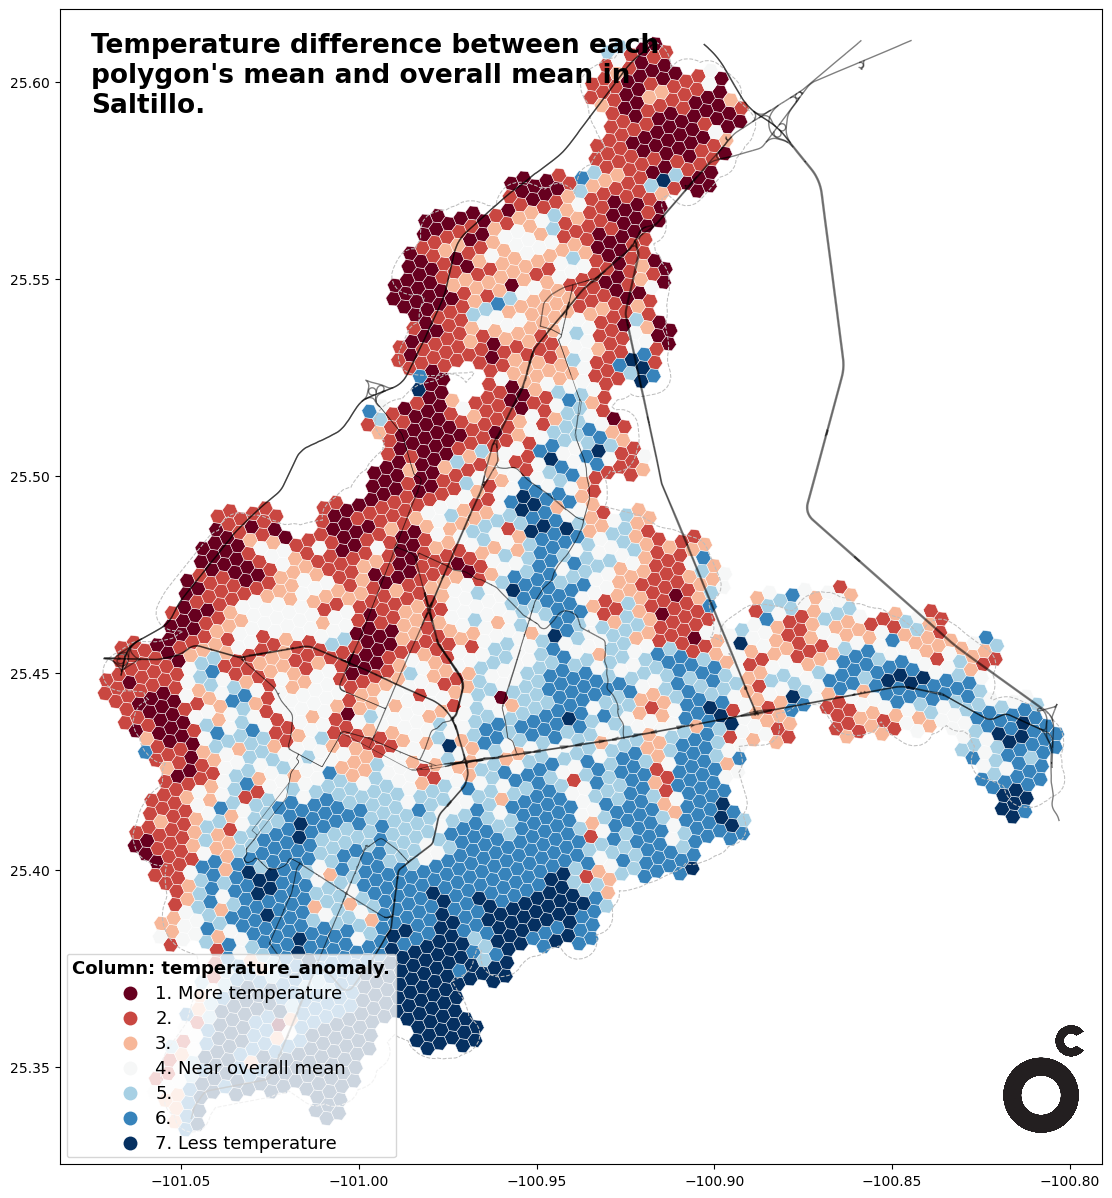

In [20]:
kwargs_dict = {"location_name":'Saltillo',
               "plot_osmnx_edges": (True, edges_gdf),
               "plot_boundary": (True, aoi_gdf),
               "save_png":(True,output_dir+'temperature_anomaly'),
               "output_transparency":True,
               "output_dpi":150
              }

fig,ax = plt.subplots(figsize=(15,15))
odc.plot_temperature_anomaly(data_gdf = hex_analysis_small_hexs,
                             ax=ax,
                             kwargs=kwargs_dict
                            )

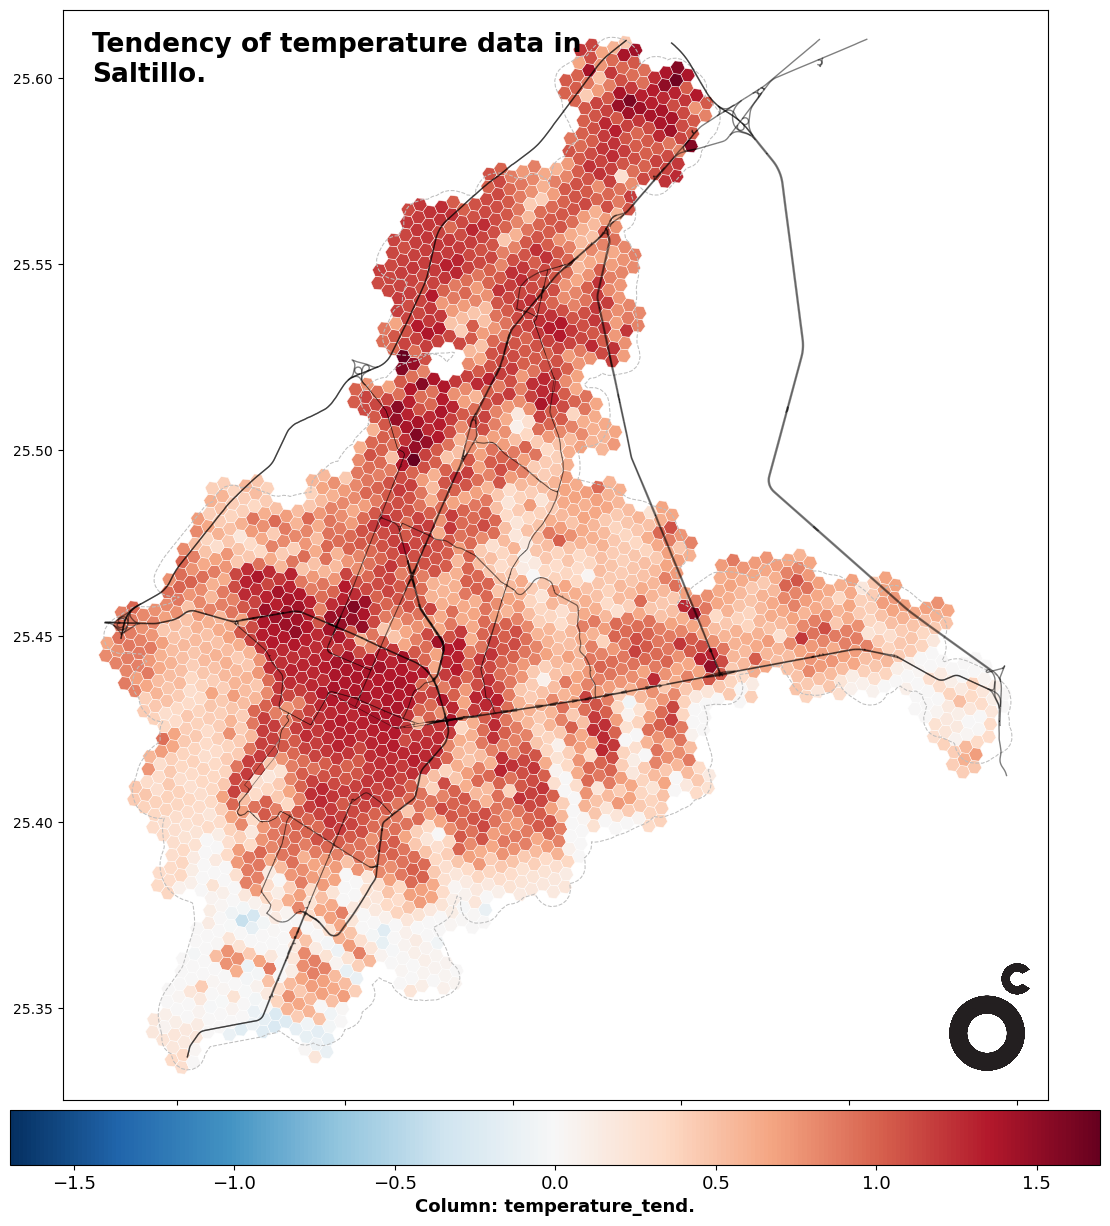

In [21]:
kwargs_dict = {"location_name":'Saltillo',
               "plot_osmnx_edges": (True, edges_gdf),
               "plot_boundary": (True, aoi_gdf),
               "save_pdf":(True,output_dir+'ndvi_tendency'),
               "output_transparency":True,
               "output_dpi":150
              }
fig,ax = plt.subplots(figsize=(15,15))

odc.plot_temperature_tendency(data_gdf = hex_analysis_small_hexs,
                              ax=ax,
                              kwargs = kwargs_dict
                             )